## Model Inference — Final Submission

In [ ]:
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    subprocess.run(["git", "clone", "https://github.com/DaTking4/ml-final-project-walmart-recruiting.git"], check=True)
    %cd ml-final-project-walmart-recruiting
    %pip install -q -r requirements.txt

    import os
    from google.colab import userdata
    os.environ["DAGSHUB_USER_TOKEN"] = userdata.get("DAGSHUB_TOKEN")
    os.environ["WANDB_API_KEY"]      = userdata.get("WANDB_API_KEY")
    os.environ["KAGGLE_API_TOKEN"]   = userdata.get("KAGGLE_API_TOKEN")

    %pip install -q kaggle
    import os; os.makedirs("data", exist_ok=True)
    !kaggle competitions download -c walmart-recruiting-store-sales-forecasting -p data/ --quiet
    !unzip -q -o data/walmart-recruiting-store-sales-forecasting.zip -d data/

print("Running in:", "Google Colab" if IN_COLAB else "Local environment")


### 1. Setup and Imports

In [9]:
import os
import sys
import importlib
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))

repo_root = Path.cwd()
while repo_root != repo_root.parent:
    if (repo_root / "src").exists():
        sys.path.insert(0, str(repo_root))
        break
    repo_root = repo_root.parent
else:
    raise FileNotFoundError("Could not locate the repository root containing 'src'.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.pyfunc

import src.mlflow_setup as mlflow_setup
importlib.reload(mlflow_setup)
init_tracking = mlflow_setup.init_tracking

from src.data_loading import load_merged
from src.transforms import apply_shared_features

init_tracking()
assert "dagshub.com" in mlflow.get_tracking_uri(), mlflow.get_tracking_uri()

BLUE, GREEN, RED = "#7196C7", "#5E9D74", "#7E3838"

print("Setup complete.")


Initialized MLflow to track repo "dkhak22/ml-final-project-store-sales-forecasting"

Repository dkhak22/ml-final-project-store-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow
Setup complete.


### 2. Configuration

In [10]:
MODEL_REGISTRY = {
    "XGBoost":  {"experiment": "XGBoost_Training",  "registered_model": "XGBoost_WalmartForecast"},
    "TimesFM":  {"experiment": "TimesFM_Training",  "registered_model": "TimesFM_WalmartForecast"},
    "Prophet":  {"experiment": "Prophet_Training",  "registered_model": "Prophet_WalmartForecast"},
    "N-BEATS":  {"experiment": "NBEATS_Training",   "registered_model": "NBEATS_WalmartForecast"},
    "LightGBM": {"experiment": "LightGBM_Training", "registered_model": "LightGBM_WalmartForecast"},
    "TFT":      {"experiment": "TFT_Training",      "registered_model": "TFT_WalmartForecast"},
    "PatchTST": {"experiment": "PatchTST_Training", "registered_model": "PatchTST_WalmartForecast"},
    "DLinear":  {"experiment": "DLinear_Training",  "registered_model": "DLinear_WalmartForecast"},
    "ARIMA":    {"experiment": "ARIMA_Training",    "registered_model": "ARIMA_WalmartForecast"},
    "SARIMA":   {"experiment": "SARIMA_Training",   "registered_model": "SARIMA_WalmartForecast"},
}

# README.md comparison table — used only when MLflow has nothing for a model.
DOCUMENTED_RESULTS = {
    "XGBoost":  1709.59,
    "TimesFM":  1815.32,
    "Prophet":  1855.10,
    "N-BEATS":  1858.23,
    "LightGBM": 1864.71,
    "TFT":      2216.19,
    "PatchTST": 2331.97,
    "DLinear":  2555.44,
    "ARIMA":    2657.08,
    "SARIMA":   None,  # notebook never completed a run — no number exists yet
}

print(f"Tracking {len(MODEL_REGISTRY)} model families.")


Tracking 10 model families.


### 3. Load Data

In [11]:
train_df, test_df = load_merged()
sample_submission = pd.read_csv(repo_root / "data" / "sampleSubmission.csv")

test_df_featurized = apply_shared_features(test_df)

print(f"train_df: {train_df.shape}")
print(f"test_df:  {test_df.shape}")
print(f"test_df_featurized: {test_df_featurized.shape}")
print(f"sampleSubmission rows: {len(sample_submission):,}")
test_df_featurized.head()


train_df: (421570, 16)
test_df:  (115064, 15)
test_df_featurized: (115064, 22)
sampleSubmission rows: 115,064


,Store,Dept,Date,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,Unemployment,Size,Type_A,Type_B,Type_C,Year,Month,WeekOfYear,DaysSinceLastHoliday,DaysToNextHoliday
0,1,1,2012-11-02,0,55.32,3.386,6766.44,5147.70,50.82,3639.90,...,6.573,151315,True,False,False,2012,11,44,56.0,21.0
1,1,1,2012-11-09,0,61.24,3.314,11421.32,3370.89,40.28,4646.79,...,6.573,151315,True,False,False,2012,11,45,63.0,14.0
2,1,1,2012-11-16,0,52.92,3.252,9696.28,292.10,103.78,1133.15,...,6.573,151315,True,False,False,2012,11,46,70.0,7.0
3,1,1,2012-11-23,1,56.23,3.211,883.59,4.17,74910.32,209.91,...,6.573,151315,True,False,False,2012,11,47,0.0,0.0
4,1,1,2012-11-30,0,52.34,3.207,2460.03,0.00,3838.35,150.57,...,6.573,151315,True,False,False,2012,11,48,7.0,28.0


### 4. Collect Best Validation Results per Model (MLflow)

In [12]:
def get_best_run(experiment_name: str):
    """Return the lowest-val_wmae finished run in an experiment, or None."""
    try:
        runs = mlflow.search_runs(
            experiment_names=[experiment_name],
            filter_string="metrics.val_wmae < 1e12 and attributes.status = 'FINISHED'",
            order_by=["metrics.val_wmae ASC"],
            max_results=1,
        )
    except Exception as exc:
        print(f"  [{experiment_name}] query failed: {exc}")
        return None

    if runs.empty:
        return None

    row = runs.iloc[0]
    return {
        "run_id": row["run_id"],
        "val_wmae": float(row["metrics.val_wmae"]),
        "label": row.get("params.label", row.get("tags.mlflow.runName", "")),
    }


results = []
for model_name, cfg in MODEL_REGISTRY.items():
    best = get_best_run(cfg["experiment"])

    if best is not None:
        results.append({
            "model": model_name,
            "val_wmae": best["val_wmae"],
            "label": best["label"],
            "run_id": best["run_id"],
            "source": "mlflow",
        })
        print(f"{model_name:10s} mlflow best: {best['val_wmae']:,.2f}  ({best['label']})")
        continue

    documented = DOCUMENTED_RESULTS.get(model_name)
    if documented is not None:
        results.append({
            "model": model_name,
            "val_wmae": documented,
            "label": "documented (README)",
            "run_id": None,
            "source": "documented",
        })
        print(f"{model_name:10s} no MLflow runs found, using documented value: {documented:,.2f}")
    else:
        print(f"{model_name:10s} no MLflow runs and no documented value — excluded")


XGBoost    mlflow best: 1,709.59  (overfit_5)
TimesFM    mlflow best: 1,815.32  (zero_shot_5)
Prophet    mlflow best: 1,855.10  (Prophet_Baseline)
N-BEATS    mlflow best: 1,858.23  (balanced_9)
LightGBM   mlflow best: 1,769.42  (balanced_18)
TFT        mlflow best: 2,216.19  (balanced_1)
PatchTST   mlflow best: 2,331.97  (overfit_1)
DLinear    mlflow best: 2,555.44  (balanced_2)
ARIMA      mlflow best: 2,657.08  (complex_5)
SARIMA     no MLflow runs and no documented value — excluded


### 5. Results Comparison

,model,val_wmae,label,run_id,source
0,XGBoost,1709.593236,overfit_5,981371efb7984ca4a06027503a52c047,mlflow
1,LightGBM,1769.418035,balanced_18,bcd3a8adbd2a4ba9bd86f3cba37e44b0,mlflow
2,TimesFM,1815.324658,zero_shot_5,aa247403c670487ea7cc4b5945c039e1,mlflow
3,Prophet,1855.097285,Prophet_Baseline,ef6df4aeff734ef7886ee95d75579cbd,mlflow
4,N-BEATS,1858.226421,balanced_9,4ffa4346c2674cb5a87954d391e2ea34,mlflow
5,TFT,2216.193649,balanced_1,c8417033444347c6a7d7f5f08a464a0c,mlflow
6,PatchTST,2331.972470,overfit_1,070edac942804450869610a8c4749719,mlflow
7,DLinear,2555.443176,balanced_2,55271adeb50e4787a6ab3f781145e628,mlflow
8,ARIMA,2657.081212,complex_5,f78cd930dbb74f63b5545cd0f35ca801,mlflow


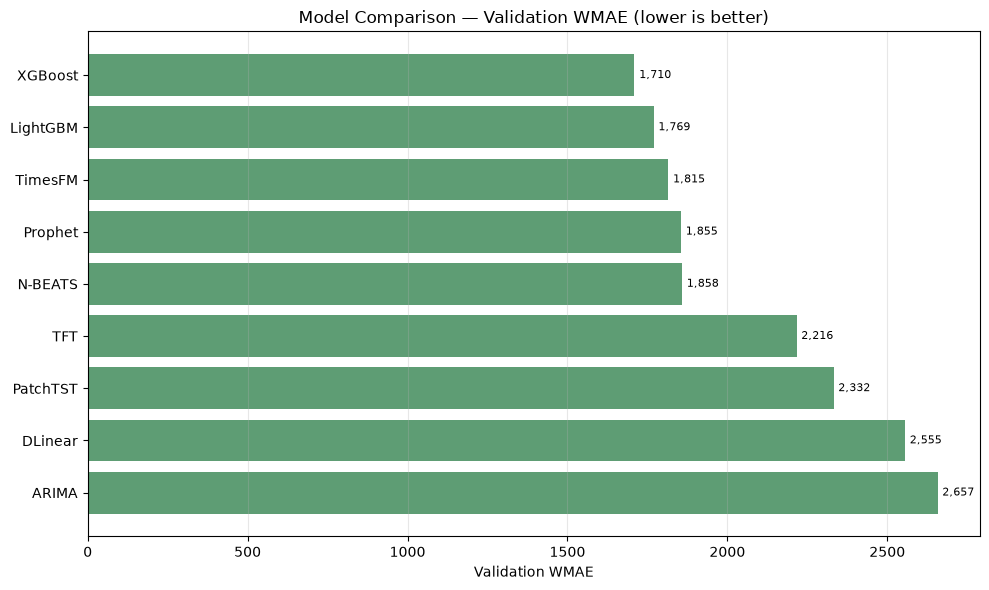


Green = live MLflow result, Blue = fallback to the documented README value.


In [13]:
results_df = pd.DataFrame(results).sort_values("val_wmae").reset_index(drop=True)
display(results_df)

os.makedirs("Plots", exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [GREEN if src == "mlflow" else BLUE for src in results_df["source"]]
ax.barh(results_df["model"], results_df["val_wmae"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Validation WMAE")
ax.set_title("Model Comparison — Validation WMAE (lower is better)")
ax.grid(axis="x", alpha=0.3)
for idx, value in enumerate(results_df["val_wmae"]):
    ax.text(value + 15, idx, f"{value:,.0f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("Plots/model_comparison_wmae.png", dpi=200)
plt.show()

print("\nGreen = live MLflow result, Blue = fallback to the documented README value.")


### 6. Select Best Model

In [14]:
candidates = results_df.to_dict("records")
assert candidates, "No model results available — nothing to select from."

print("Candidate ranking (best first):")
for row in candidates:
    print(f"  {row['model']:10s} val_wmae={row['val_wmae']:,.2f}  source={row['source']}")


Candidate ranking (best first):
  XGBoost    val_wmae=1,709.59  source=mlflow
  LightGBM   val_wmae=1,769.42  source=mlflow
  TimesFM    val_wmae=1,815.32  source=mlflow
  Prophet    val_wmae=1,855.10  source=mlflow
  N-BEATS    val_wmae=1,858.23  source=mlflow
  TFT        val_wmae=2,216.19  source=mlflow
  PatchTST   val_wmae=2,331.97  source=mlflow
  DLinear    val_wmae=2,555.44  source=mlflow
  ARIMA      val_wmae=2,657.08  source=mlflow


### 7. Load Best Model from MLflow Registry

In [15]:
loaded_model = None
chosen = None

for row in candidates:
    registered_name = MODEL_REGISTRY[row["model"]]["registered_model"]
    model_uri = f"models:/{registered_name}/latest"
    try:
        loaded_model = mlflow.pyfunc.load_model(model_uri)
        chosen = row
        print(f"Loaded '{registered_name}' (val_wmae={row['val_wmae']:,.2f}) from {model_uri}")
        break
    except Exception as exc:
        print(f"Could not load '{registered_name}': {exc}\n  Falling back to next-best model...")

assert loaded_model is not None, "None of the candidate models could be loaded from the registry."


2026/07/13 02:16:33 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - mlflow (current: 3.14.0, required: mlflow==2.17.2)
 - numpy (current: 2.4.6, required: numpy==1.26.4)
 - pandas (current: 2.3.3, required: pandas==2.2.2)
 - scikit-learn (current: 1.9.0, required: scikit-learn==1.5.2)
 - scipy (current: 1.15.3, required: scipy==1.13.1)
 - xgboost (current: 3.3.0, required: xgboost==3.2.0)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
2026/07/13 02:16:33 WARNING mlflow.pyfunc: The version of Python that the model was saved in, `Python 3.11.15`, differs from the version of Python that is currently running, `Python 3.12.10`, and may be incompatible


Loaded 'XGBoost_WalmartForecast' (val_wmae=1,709.59) from models:/XGBoost_WalmartForecast/latest


### 8. Generate Test Predictions

In [16]:
predictions = loaded_model.predict(test_df_featurized)

assert set(predictions.columns) == {"Id", "Weekly_Sales"}
assert len(predictions) == len(test_df), (
    f"Expected {len(test_df)} predictions, got {len(predictions)}"
)
assert predictions["Weekly_Sales"].notna().all(), "Predictions contain NaN values"
assert (predictions["Weekly_Sales"] >= 0).all(), "Predictions contain negative Weekly_Sales"

missing_ids = set(sample_submission["Id"]) - set(predictions["Id"])
extra_ids = set(predictions["Id"]) - set(sample_submission["Id"])
assert not missing_ids, f"Missing {len(missing_ids)} Id(s) present in sampleSubmission.csv, e.g. {list(missing_ids)[:5]}"
assert not extra_ids, f"Predictions contain {len(extra_ids)} unexpected Id(s), e.g. {list(extra_ids)[:5]}"

print(f"Generated {len(predictions):,} predictions with model: {chosen['model']}")
predictions.head()


c:\Users\l.chitishvili\Desktop\ml\ml-final-project-store-sales-forecasting\src\xgb_utils.py:46: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["Store", "Dept"], group_keys=False).apply(_group_feats)


Generated 115,064 predictions with model: XGBoost


,Id,Weekly_Sales
0,1_1_2012-11-02,46890.644531
1,1_1_2012-11-09,20651.115234
2,1_1_2012-11-16,21189.953125
3,1_1_2012-11-23,23258.861328
4,1_1_2012-11-30,26791.285156


### 9. Save Submission

In [18]:
os.makedirs("submissions", exist_ok=True)
submission_path = repo_root / "submissions" / "submission.csv"

# Match sampleSubmission.csv row order.
submission = sample_submission[["Id"]].merge(predictions, on="Id", how="left")
assert submission["Weekly_Sales"].notna().all(), "Merge produced missing predictions"

submission.to_csv(submission_path, index=False)

print(f"Best model:      {chosen['model']}")
print(f"Validation WMAE: {chosen['val_wmae']:,.2f}  (source: {chosen['source']})")
print(f"Submission saved to: {submission_path}")
submission.head()


Best model:      XGBoost
Validation WMAE: 1,709.59  (source: mlflow)
Submission saved to: c:\Users\l.chitishvili\Desktop\ml\ml-final-project-store-sales-forecasting\submissions\submission.csv


,Id,Weekly_Sales
0,1_1_2012-11-02,46890.644531
1,1_1_2012-11-09,20651.115234
2,1_1_2012-11-16,21189.953125
3,1_1_2012-11-23,23258.861328
4,1_1_2012-11-30,26791.285156
